# QADD v4.2.0 reviewed preflight

**Family:** Recorded pause-region additive-interference manifestations  
**Purpose:** Execute G1-G5 analytical validation before any corrected cohort extraction.  

This notebook does **not** access diagnosis or human-QC labels and does not create a family scalar or accept/reject threshold. It tests the five retained candidate measurements, the corrected strict-speech contract, the corrected hum-support bookkeeping, and the principal non-identifiability/confound controls.

## 0. Environment and run controls

In [1]:
from __future__ import annotations

from dataclasses import asdict
from hashlib import sha256
from pathlib import Path
from tempfile import TemporaryDirectory
import json
import math
import os
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal
from IPython.display import display, Markdown


def find_project_root() -> Path:
    override = os.environ.get("PAPER1_PROJECT_ROOT", "").strip()
    if override:
        candidate = Path(override).expanduser().resolve()
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
        raise FileNotFoundError(f"PAPER1_PROJECT_ROOT is invalid: {candidate}")
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "Open this notebook from inside the Paper 1 pipeline repository, "
        "or set PAPER1_PROJECT_ROOT to the project root."
    )

ROOT = find_project_root()
REVIEWED_SRC = ROOT / "src reviewed"
ORIGINAL_SRC = ROOT / "src"
for path in [REVIEWED_SRC, ORIGINAL_SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from paper1_qc_reviewed.qadd_v420 import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    MEASUREMENT_VERSION,
    TimeInterval,
    ac_rms_measurement,
    apply_hum_null_calibration,
    compare_reconstruction,
    extract_qadd,
    feature_registry_frame,
)

RUN_PACKAGE_TESTS = True
RUN_CODEC_ROUNDTRIP = True
PUBLISH_AND_FREEZE = False
SCIENTIFIC_REVIEW_DECISION = "PENDING"

PARAMETERS = DEFAULT_PARAMETERS
FS = PARAMETERS.analysis_sample_rate_hz
RNG = np.random.default_rng(PARAMETERS.random_seed)

STAGE = ROOT / "outputs reviewed" / "additive_interference" / MEASUREMENT_VERSION
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
VALIDATION = STAGE / "validation"
AUDIT = STAGE / "audit"
MANIFESTS = STAGE / "manifests"
for directory in [TABLES, FIGURES, VALIDATION, AUDIT, MANIFESTS]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Measurement:", MEASUREMENT_VERSION)
print("Output stage:", STAGE)

Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Measurement: qadd-v4.2.0-candidate
Output stage: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs reviewed\additive_interference\qadd-v4.2.0-candidate


## 1. G1 - Scientific contract and feature registry

The reviewed candidate retains five separate measurements. `strict_speech` and `strict_internal_nonspeech` are treated as already-guarded frozen inputs during cohort extraction; the extractor must not apply a second speech-edge guard.

In [2]:
registry = feature_registry_frame().copy()
registry["reviewed_candidate_role"] = registry["feature"].map({
    "qadd_pause_ac_level_dbfs_median": "primary contextual acquisition measurement",
    "qadd_pause_level_iqr_db": "secondary nonstationarity descriptor",
    "qadd_speech_pause_level_contrast_db": "secondary mixed speech/acquisition descriptor",
    "qadd_pause_spectral_flatness": "secondary nonordinal spectral-type descriptor",
    "qadd_mains_hum_comb_score_db": "targeted hum-like structure descriptor",
})
registry["standalone_gate_allowed"] = False
registry["family_scalar_allowed"] = False
registry.to_csv(TABLES / "qadd_v420_feature_registry.csv", index=False)
pd.DataFrame([PARAMETERS.to_dict()]).to_csv(TABLES / "qadd_v420_parameters.csv", index=False)
(Path(AUDIT) / "qadd_v420_parameters.json").write_text(json.dumps(PARAMETERS.to_dict(), indent=2), encoding="utf-8")
display(registry)

,measurement_version,feature,display_name,role,unit,direction,estimator,construct,establishment,claim_limit,...,positive_control,discriminant_control,known_confounding,signal_view,missing_value_behavior,analysis_eligible,composite_use_prohibited,reviewed_candidate_role,standalone_gate_allowed,family_scalar_allowed
0,qadd-v4.2.0-candidate,qadd_pause_ac_level_dbfs_median,Guarded-pause AC level (median),primary,analysis-view dBFS,higher means more recorded non-floor pause energy,median 30-ms AC-RMS frame level; 10-ms hop,recorded pause energy consistent with extrinsi...,RMS/dBFS are established; the guarded-pause ap...,"not dB SPL, native-stream dBFS, environmental ...",...,unit-slope response to injected pause-noise level,independent of noise spectral color at matched...,"device gain, distance, room noise, channel pro...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True,primary contextual acquisition measurement,False,False
1,qadd-v4.2.0-candidate,qadd_pause_level_iqr_db,Guarded-pause level IQR,secondary,dB,contextual; higher means greater within-record...,Q75 minus Q25 of eligible pause-frame AC levels,temporal heterogeneity of recorded pause energy,IQR is established robust dispersion; this app...,not an ordinal severity measure and sensitive ...,...,increases under amplitude-modulated or changin...,invariant to global gain,"number/distribution of pauses, transient resid...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True,secondary nonstationarity descriptor,False,False
2,qadd-v4.2.0-candidate,qadd_speech_pause_level_contrast_db,Speech-pause level contrast,mixed_secondary,dB,lower means less within-recording level separa...,median strict-speech AC level minus median gua...,within-recording speech-to-pause level separation,level contrast is established; interpretation ...,not physical SNR; also depends on speech inten...,...,decreases as injected pause-noise level rises,invariant to global gain,"speech intensity, bulbar impairment, microphon...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True,secondary mixed speech/acquisition descriptor,False,False
3,qadd-v4.2.0-candidate,qadd_pause_spectral_flatness,Guarded-pause spectral flatness,secondary_descriptor,ratio,non-ordinal; high is broadband-like and low is...,median power-spectrum flatness from 80-7000 Hz...,spectral type of recorded pause interference,spectral flatness is established; the band/agg...,neither endpoint is universally worse; channel...,...,higher for broadband noise than tonal interfer...,invariant to global gain; low for off-grid tones,"channel bandwidth, codec filtering, spectral c...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True,secondary nonordinal spectral-type descriptor,False,False
4,qadd-v4.2.0-candidate,qadd_mains_hum_comb_score_db,50/60-Hz mains-hum comb score,targeted_descriptor,dB,higher means stronger 50/60-Hz harmonic structure,max 50/60-Hz median local contrast across harm...,mains-frequency harmonic interference in recor...,harmonic prominence is established; this exact...,not a perceptual threshold; requires off-grid ...,...,increases for 50/60-Hz harmonic combs,colored-noise and 53-Hz off-grid nulls,"frequency drift, narrowband machinery, spectra...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True,targeted hum-like structure descriptor,False,False


## Shared synthetic fixture and artifact helpers

In [3]:
def db_to_amp(dbfs: float) -> float:
    return float(10.0 ** (dbfs / 20.0))


def colored_noise(n: int, color: str, rng: np.random.Generator) -> np.ndarray:
    x = rng.normal(size=n)
    if color == "white":
        y = x
    else:
        f = np.fft.rfftfreq(n, 1 / FS)
        spectrum = np.fft.rfft(x)
        exponent = {"pink": 0.5, "brown": 1.0}[color]
        weight = np.ones_like(f)
        weight[1:] = np.maximum(f[1:], 1.0) ** (-exponent)
        spectrum *= weight
        y = np.fft.irfft(spectrum, n=n)
    y = y - y.mean()
    return y / max(np.sqrt(np.mean(y * y)), np.finfo(float).tiny)


def speech_pause_fixture(
    *,
    pause_dbfs: float = -50.0,
    speech_dbfs: float = -20.0,
    color: str = "white",
    am_depth_db: float = 0.0,
    seed: int = 2026,
):
    duration = 18.0
    t = np.arange(round(duration * FS)) / FS
    primary = [
        TimeInterval(0.0, 2.5), TimeInterval(3.5, 6.0), TimeInterval(7.0, 9.5),
        TimeInterval(10.5, 13.0), TimeInterval(14.0, 18.0),
    ]
    pauses = [TimeInterval(2.7, 3.3), TimeInterval(6.2, 6.8), TimeInterval(9.7, 10.3), TimeInterval(13.2, 13.8)]
    strict_speech = [TimeInterval(x.start_sec + 0.05, x.end_sec - 0.05) for x in primary]
    rng = np.random.default_rng(seed)
    pause = colored_noise(len(t), color, rng)
    if am_depth_db:
        envelope_db = am_depth_db * np.sin(2 * np.pi * 1.6 * t)
        pause = pause * 10 ** (envelope_db / 20.0)
        pause = pause / np.sqrt(np.mean(pause * pause))
    waveform = pause * db_to_amp(pause_dbfs)
    speech_mask = np.zeros(len(t), dtype=bool)
    for interval in primary:
        speech_mask[round(interval.start_sec * FS):round(interval.end_sec * FS)] = True
    speech = (
        np.sin(2*np.pi*145*t) + 0.45*np.sin(2*np.pi*290*t) + 0.2*np.sin(2*np.pi*435*t)
    )
    speech = speech / np.sqrt(np.mean(speech[speech_mask] ** 2))
    waveform[speech_mask] += speech[speech_mask] * db_to_amp(speech_dbfs)
    return waveform, primary, strict_speech, pauses


def add_comb(waveform: np.ndarray, intervals, fundamental: float, comb_dbfs: float, drift_hz: float = 0.0):
    y = waveform.copy()
    t = np.arange(len(y))/FS
    phase = 2*np.pi*(fundamental*t + 0.5*drift_hz*t*t/max(t[-1], 1e-9))
    comb = np.zeros_like(y)
    for harmonic, relative in [(1,1.0),(2,0.6),(3,0.35),(4,0.2)]:
        comb += relative*np.sin(harmonic*phase)
    mask=np.zeros(len(y),dtype=bool)
    for interval in intervals:
        mask[round(interval.start_sec*FS):round(interval.end_sec*FS)]=True
    rms=np.sqrt(np.mean(comb[mask]**2))
    comb *= db_to_amp(comb_dbfs)/max(rms,np.finfo(float).tiny)
    y[mask]+=comb[mask]
    return y


def add_single_tone(waveform, intervals, frequency, tone_dbfs):
    y=waveform.copy(); t=np.arange(len(y))/FS
    tone=np.sin(2*np.pi*frequency*t)
    mask=np.zeros(len(y),dtype=bool)
    for interval in intervals:
        mask[round(interval.start_sec*FS):round(interval.end_sec*FS)]=True
    tone*=db_to_amp(tone_dbfs)/np.sqrt(np.mean(tone[mask]**2))
    y[mask]+=tone[mask]
    return y


def extract_fixture(waveform, primary, strict_speech, pauses, recording_id="synthetic"):
    return extract_qadd(
        waveform,
        FS,
        primary_speech=primary,
        strict_speech=strict_speech,
        strict_internal_nonspeech=pauses,
        speech_intervals_are_guarded=True,
        pause_intervals_are_guarded=True,
        logical_recording_id=recording_id,
    )


def save_table(frame: pd.DataFrame, name: str):
    frame.to_csv(TABLES/name, index=False)


def save_figure(fig, stem: str, source: pd.DataFrame, caption: str, provenance: dict):
    png=FIGURES/f"{stem}.png"; svg=FIGURES/f"{stem}.svg"; pdf=FIGURES/f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    source_path=FIGURES/f"{stem}.source.csv"; source.to_csv(source_path,index=False)
    (FIGURES/f"{stem}.caption.md").write_text(caption,encoding="utf-8")
    payload={"measurement_version":MEASUREMENT_VERSION,"figure":stem,"source_data":source_path.name,**provenance}
    (FIGURES/f"{stem}.provenance.json").write_text(json.dumps(payload,indent=2),encoding="utf-8")
    plt.show()

## 2. G2 - Numerical correctness, corrected guarding, and reconstruction

In [4]:
base, primary, strict_speech, pauses = speech_pause_fixture(seed=100)
extraction = extract_fixture(base, primary, strict_speech, pauses, "g2")
reconstruction = compare_reconstruction(extraction)

# Analytic sine check.
t = np.arange(round(0.03*FS))/FS
sine = 0.1*np.sin(2*np.pi*1000*t)
level_db, rms, at_floor, exact_zero = ac_rms_measurement(sine)
expected_rms=0.1/np.sqrt(2)
expected_db=20*np.log10(expected_rms)

# Prove no second strict-speech erosion.
direct = extract_qadd(
    base, FS, primary_speech=primary, strict_speech=strict_speech,
    strict_internal_nonspeech=pauses, speech_intervals_are_guarded=True,
    pause_intervals_are_guarded=True, logical_recording_id="direct"
)
double_guard = extract_qadd(
    base, FS, primary_speech=primary, strict_speech=strict_speech,
    strict_internal_nonspeech=pauses, speech_intervals_are_guarded=False,
    pause_intervals_are_guarded=True, logical_recording_id="double"
)
direct_frames=int(direct.frame_ledger.region.eq("speech").sum())
double_frames=int(double_guard.frame_ledger.region.eq("speech").sum())

checks = pd.DataFrame([
    {"check":"sine AC-RMS", "passed":np.isclose(rms,expected_rms,atol=1e-12), "observed":rms, "required":expected_rms},
    {"check":"sine dBFS", "passed":np.isclose(level_db,expected_db,atol=1e-12), "observed":level_db, "required":expected_db},
    {"check":"all raw estimands reconstruct", "passed":bool(reconstruction["pass"].all()), "observed":f"{int(reconstruction['pass'].sum())}/{len(reconstruction)}", "required":f"{len(reconstruction)}/{len(reconstruction)}"},
    {"check":"canonical strict speech receives no second guard", "passed":direct_frames>double_frames and direct.recording['qadd_speech_guard_applied_ms']==0.0, "observed":f"direct={direct_frames}; double={double_frames}", "required":"direct > double and applied guard=0"},
])
save_table(checks,"qadd_v420_g2_checks.csv")
save_table(reconstruction,"qadd_v420_reconstruction_control.csv")
display(checks)
assert checks.passed.all()

,check,passed,observed,required
0,sine AC-RMS,True,0.070711,0.070711
1,sine dBFS,True,-23.0103,-23.0103
2,all raw estimands reconstruct,True,11/11,11/11
3,canonical strict speech receives no second guard,True,direct=1340; double=1290,direct > double and applied guard=0


## 3. G3 - Transformation behavior

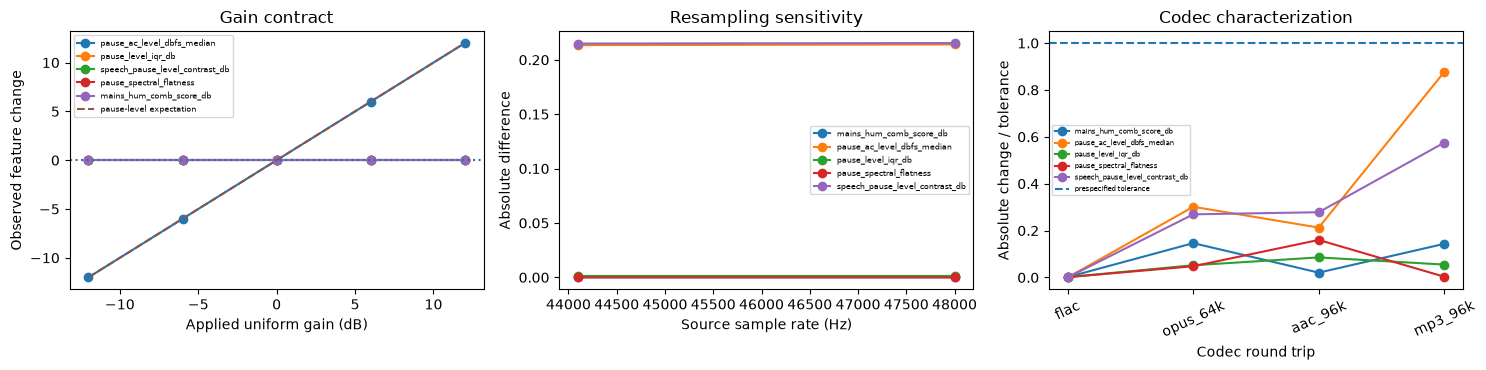

,check,passed,observed,required
0,pause level gain equivariance,True,0.0,<1e-8 dB
1,relative/shape gain invariance,True,0.0,<1e-8
2,polarity invariance,True,evaluated,all <1e-8
3,DC-offset invariance after local mean removal,True,evaluated,all <1e-8
4,common time-shift invariance,True,evaluated,all <1e-8
5,lossless codec regression,True,0.002409,maximum absolute change <0.01 in native featur...
6,lossy codec preflight tolerances,True,0.876813,all feature-specific tolerance ratios <=1.0


In [5]:
transform_rows=[]
reference=extract_fixture(base,primary,strict_speech,pauses,"reference").recording
for gain_db in [-12,-6,0,6,12]:
    y=base*db_to_amp(gain_db)
    r=extract_fixture(y,primary,strict_speech,pauses,f"gain_{gain_db}").recording
    transform_rows.append({"condition":"gain","dose":gain_db,**{f:r[f] for f in ANALYSIS_FEATURES}})
for name,y in [
    ("polarity",-base),
    ("dc_offset",base+0.02),
]:
    r=extract_fixture(y,primary,strict_speech,pauses,name).recording
    transform_rows.append({"condition":name,"dose":0,**{f:r[f] for f in ANALYSIS_FEATURES}})
# Common waveform/interval time shift by 0.5 s.
pad=np.zeros(round(.5*FS)); shifted=np.concatenate([pad,base])
shifted_primary=[TimeInterval(x.start_sec+.5,x.end_sec+.5) for x in primary]
shifted_speech=[TimeInterval(x.start_sec+.5,x.end_sec+.5) for x in strict_speech]
shifted_pauses=[TimeInterval(x.start_sec+.5,x.end_sec+.5) for x in pauses]
r=extract_fixture(shifted,shifted_primary,shifted_speech,shifted_pauses,"time_shift").recording
transform_rows.append({"condition":"time_shift","dose":.5,**{f:r[f] for f in ANALYSIS_FEATURES}})
transform=pd.DataFrame(transform_rows)

# Resampling-only characterization.
resample_rows=[]
for source_fs in [44100,48000]:
    n=round(len(base)*source_fs/FS)
    source=signal.resample(base,n)
    restored=signal.resample_poly(source,FS,source_fs)[:len(base)]
    rr=extract_fixture(restored,primary,strict_speech,pauses,f"resample_{source_fs}").recording
    resample_rows.append({"source_sample_rate_hz":source_fs,**{f"{f}_difference":rr[f]-reference[f] for f in ANALYSIS_FEATURES}})
resampling=pd.DataFrame(resample_rows)

# Versioned codec round-trip characterization. Lossy codecs are not assumed to
# be irrelevant; they are bounded using feature-specific preflight tolerances.
codec_tolerances={
    'qadd_pause_ac_level_dbfs_median':1.0,
    'qadd_pause_level_iqr_db':0.50,
    'qadd_speech_pause_level_contrast_db':0.75,
    'qadd_pause_spectral_flatness':0.03,
    'qadd_mains_hum_comb_score_db':1.50,
}
codec_rows=[]
if RUN_CODEC_ROUNDTRIP:
    if shutil.which('ffmpeg') is None:
        raise RuntimeError('RUN_CODEC_ROUNDTRIP=True but ffmpeg is not available on PATH')
    with TemporaryDirectory() as temporary_directory:
        temporary_directory=Path(temporary_directory)
        source_wav=temporary_directory/'qadd_reference.wav'
        sf.write(source_wav,base,FS,subtype='PCM_24')
        codec_specs=[
            ('flac',['-c:a','flac'],'.flac','lossless'),
            ('opus_64k',['-c:a','libopus','-b:a','64k'],'.opus','lossy'),
            ('aac_96k',['-c:a','aac','-b:a','96k'],'.m4a','lossy'),
            ('mp3_96k',['-c:a','libmp3lame','-b:a','96k'],'.mp3','lossy'),
        ]
        for codec,arguments,suffix,codec_class in codec_specs:
            encoded=temporary_directory/f'{codec}{suffix}'
            decoded=temporary_directory/f'{codec}_decoded.wav'
            subprocess.run(['ffmpeg','-y','-loglevel','error','-i',str(source_wav),*arguments,str(encoded)],check=True)
            subprocess.run(['ffmpeg','-y','-loglevel','error','-i',str(encoded),'-ar',str(FS),'-ac','1',str(decoded)],check=True)
            restored,restored_fs=sf.read(decoded,dtype='float64')
            if restored_fs!=FS:
                raise RuntimeError(f'Unexpected decoded sample rate for {codec}: {restored_fs}')
            if len(restored)<len(base):
                restored=np.pad(restored,(0,len(base)-len(restored)))
            restored=restored[:len(base)]
            rr=extract_fixture(restored,primary,strict_speech,pauses,f'codec_{codec}').recording
            for feature in ANALYSIS_FEATURES:
                difference=float(rr[feature]-reference[feature])
                tolerance=float(codec_tolerances[feature])
                codec_rows.append({
                    'codec':codec,'codec_class':codec_class,'feature':feature,
                    'difference':difference,'absolute_difference':abs(difference),
                    'tolerance':tolerance,'tolerance_ratio':abs(difference)/tolerance,
                })
codec=pd.DataFrame(codec_rows)

# Feature-specific invariance/equivariance errors.
gain=transform[transform.condition.eq('gain')].copy()
base0=gain.loc[gain.dose.eq(0)].iloc[0]
errors=[]
for _,row in gain.iterrows():
    for f in ANALYSIS_FEATURES:
        expected=row.dose if f=='qadd_pause_ac_level_dbfs_median' else 0.0
        observed=row[f]-base0[f]
        errors.append({'feature':f,'gain_db':row.dose,'expected_change':expected,'observed_change':observed,'absolute_error':abs(observed-expected)})
errors=pd.DataFrame(errors)

lossless_max=float(codec.loc[codec.codec_class.eq('lossless'),'absolute_difference'].max()) if len(codec) else np.nan
lossy_ratio_max=float(codec.loc[codec.codec_class.eq('lossy'),'tolerance_ratio'].max()) if len(codec) else np.nan
checks=pd.DataFrame([
    {'check':'pause level gain equivariance','passed':errors.loc[errors.feature.eq('qadd_pause_ac_level_dbfs_median'),'absolute_error'].max()<1e-8,'observed':errors.loc[errors.feature.eq('qadd_pause_ac_level_dbfs_median'),'absolute_error'].max(),'required':'<1e-8 dB'},
    {'check':'relative/shape gain invariance','passed':errors.loc[~errors.feature.eq('qadd_pause_ac_level_dbfs_median'),'absolute_error'].max()<1e-8,'observed':errors.loc[~errors.feature.eq('qadd_pause_ac_level_dbfs_median'),'absolute_error'].max(),'required':'<1e-8'},
    {'check':'polarity invariance','passed':max(abs(transform.loc[transform.condition.eq('polarity'),f].iloc[0]-reference[f]) for f in ANALYSIS_FEATURES)<1e-8,'observed':'evaluated','required':'all <1e-8'},
    {'check':'DC-offset invariance after local mean removal','passed':max(abs(transform.loc[transform.condition.eq('dc_offset'),f].iloc[0]-reference[f]) for f in ANALYSIS_FEATURES)<1e-8,'observed':'evaluated','required':'all <1e-8'},
    {'check':'common time-shift invariance','passed':max(abs(transform.loc[transform.condition.eq('time_shift'),f].iloc[0]-reference[f]) for f in ANALYSIS_FEATURES)<1e-8,'observed':'evaluated','required':'all <1e-8'},
    {'check':'lossless codec regression','passed':bool(np.isfinite(lossless_max) and lossless_max<0.01),'observed':lossless_max,'required':'maximum absolute change <0.01 in native feature units'},
    {'check':'lossy codec preflight tolerances','passed':bool(np.isfinite(lossy_ratio_max) and lossy_ratio_max<=1.0),'observed':lossy_ratio_max,'required':'all feature-specific tolerance ratios <=1.0'},
])
save_table(transform,'qadd_v420_transform_controls.csv')
save_table(resampling,'qadd_v420_resampling_controls.csv')
save_table(codec,'qadd_v420_codec_roundtrip_controls.csv')
save_table(pd.DataFrame([{'feature':k,'tolerance':v} for k,v in codec_tolerances.items()]),'qadd_v420_codec_tolerances.csv')
save_table(errors,'qadd_v420_gain_error.csv')
save_table(checks,'qadd_v420_g3_checks.csv')

fig,axes=plt.subplots(1,3,figsize=(15,3.8))
for f in ANALYSIS_FEATURES:
    local=errors[errors.feature.eq(f)]
    axes[0].plot(local.gain_db,local.observed_change,marker='o',label=f.replace('qadd_',''))
axes[0].plot([-12,12],[-12,12],linestyle='--',label='pause-level expectation')
axes[0].axhline(0,linestyle=':')
axes[0].set(xlabel='Applied uniform gain (dB)',ylabel='Observed feature change',title='Gain contract')
axes[0].legend(fontsize=6)
res_long=resampling.melt('source_sample_rate_hz',var_name='feature',value_name='difference')
res_long['feature']=res_long.feature.str.replace('_difference','',regex=False).str.replace('qadd_','',regex=False)
for f,local in res_long.groupby('feature'):
    axes[1].plot(local.source_sample_rate_hz,local.difference.abs(),marker='o',label=f)
axes[1].set(xlabel='Source sample rate (Hz)',ylabel='Absolute difference',title='Resampling sensitivity')
axes[1].legend(fontsize=6)
for f,local in codec.groupby('feature'):
    axes[2].plot(local.codec,local.tolerance_ratio,marker='o',label=f.replace('qadd_',''))
axes[2].axhline(1.0,linestyle='--',label='prespecified tolerance')
axes[2].set(xlabel='Codec round trip',ylabel='Absolute change / tolerance',title='Codec characterization')
axes[2].tick_params(axis='x',rotation=25)
axes[2].legend(fontsize=5)
fig.tight_layout()
source=pd.concat([
    errors.assign(table='gain'),res_long.assign(table='resampling'),codec.assign(table='codec')
],ignore_index=True,sort=False)
save_figure(fig,'C_transformation_contract',source,'QADD transformation behavior. Pause level is gain-equivariant while relative/shape features are gain-invariant. Resampling and codec round trips are characterized separately using feature-specific units and prespecified codec tolerances.',{'evidence_type':'synthetic deterministic transformation controls'})
display(checks)
assert checks.passed.all()

## 4. G4 - Controlled construct response

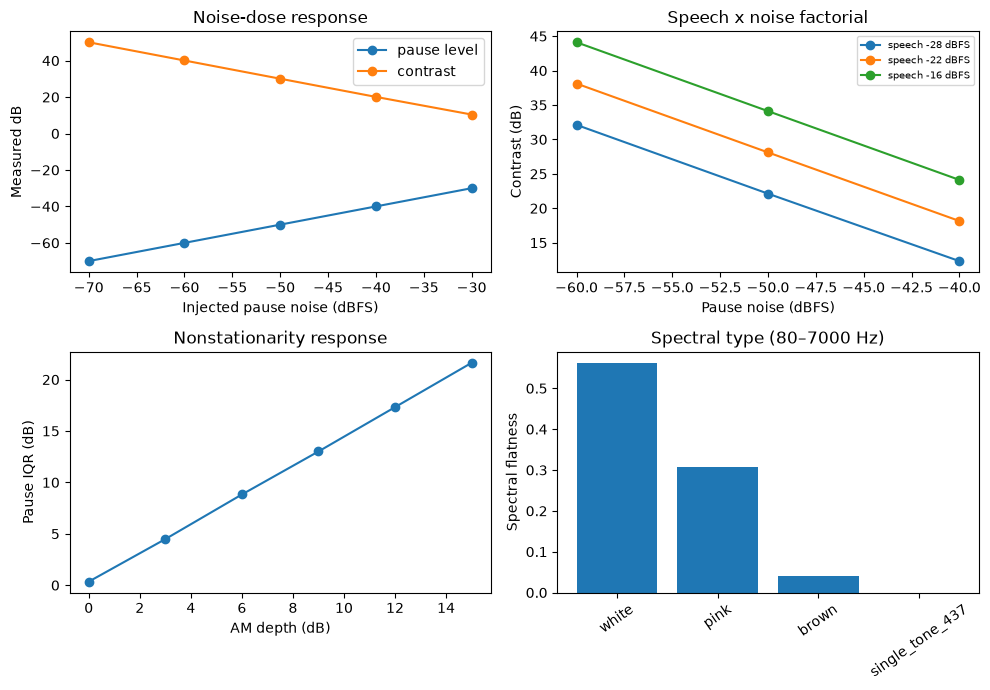

,check,passed,observed,required
0,pause level monotonic with noise dose,True,1.0,>0.99
1,contrast decreases with noise dose,True,-1.0,<-0.99
2,contrast rises with independent speech level,True,all noise strata,rho>0.99
3,contrast falls with independent pause noise,True,all speech strata,rho<-0.99
4,IQR rises with AM depth,True,1.0,>0.95
5,white flatness exceeds colored and in-band ton...,True,0.56118,"greater than pink, brown, and 437-Hz tone; 50/..."
6,hum score rises with injected comb level,True,both 50/60,rho>0.95


In [6]:
# Noise dose and speech-level x noise-level factorial.
dose_rows=[]
for noise_db in [-70,-60,-50,-40,-30]:
    y,p,s,pa=speech_pause_fixture(pause_dbfs=noise_db,speech_dbfs=-20,seed=110)
    r=extract_fixture(y,p,s,pa,f"noise_{noise_db}").recording
    dose_rows.append({'control':'pause_noise_dose','pause_noise_dbfs':noise_db,'speech_dbfs':-20,**{f:r[f] for f in ANALYSIS_FEATURES}})
factorial=[]
for speech_db in [-28,-22,-16]:
    for noise_db in [-60,-50,-40]:
        y,p,s,pa=speech_pause_fixture(pause_dbfs=noise_db,speech_dbfs=speech_db,seed=111)
        r=extract_fixture(y,p,s,pa,f"factorial_{speech_db}_{noise_db}").recording
        factorial.append({'speech_dbfs':speech_db,'pause_noise_dbfs':noise_db,'contrast_db':r['qadd_speech_pause_level_contrast_db'],'pause_level_dbfs':r['qadd_pause_ac_level_dbfs_median']})
# AM/IQR dose.
am_rows=[]
for depth in [0,3,6,9,12,15]:
    y,p,s,pa=speech_pause_fixture(pause_dbfs=-50,speech_dbfs=-20,am_depth_db=depth,seed=112)
    r=extract_fixture(y,p,s,pa,f"am_{depth}").recording
    am_rows.append({'am_depth_db':depth,'pause_iqr_db':r['qadd_pause_level_iqr_db'],'pause_level_dbfs':r['qadd_pause_ac_level_dbfs_median']})
# Spectral type.
spectral=[]
for color in ['white','pink','brown']:
    y,p,s,pa=speech_pause_fixture(pause_dbfs=-45,color=color,seed=113)
    r=extract_fixture(y,p,s,pa,color).recording
    spectral.append({'control':color,'flatness':r['qadd_pause_spectral_flatness'],'hum_score_db':r['qadd_mains_hum_comb_score_db']})
y,p,s,pa=speech_pause_fixture(pause_dbfs=-70,seed=114)
for name,freq in [('single_tone_437',437),('single_tone_50',50),('single_tone_60',60)]:
    yy=add_single_tone(y,pa,freq,-35)
    r=extract_fixture(yy,p,s,pa,name).recording
    spectral.append({'control':name,'flatness':r['qadd_pause_spectral_flatness'],'hum_score_db':r['qadd_mains_hum_comb_score_db']})
# Hum dose and drift.
hum=[]
for fundamental in [50,60]:
    for level in [-50,-44,-38,-32,-26]:
        yy=add_comb(y,pa,fundamental,level)
        r=extract_fixture(yy,p,s,pa,f"hum_{fundamental}_{level}").recording
        hum.append({'fundamental_hz':fundamental,'comb_dbfs':level,'drift_hz':0,'score_db':r['qadd_mains_hum_comb_score_db'],'supported_harmonics':r['qadd_mains_hum_supported_harmonic_count_median']})
for drift in [0,1,2,3,5]:
    yy=add_comb(y,pa,50,-32,drift_hz=drift)
    r=extract_fixture(yy,p,s,pa,f"drift_{drift}").recording
    hum.append({'fundamental_hz':50,'comb_dbfs':-32,'drift_hz':drift,'score_db':r['qadd_mains_hum_comb_score_db'],'supported_harmonics':r['qadd_mains_hum_supported_harmonic_count_median']})

dose=pd.DataFrame(dose_rows); factorial=pd.DataFrame(factorial); am=pd.DataFrame(am_rows); spectral=pd.DataFrame(spectral); hum=pd.DataFrame(hum)
for frame,name in [(dose,'qadd_v420_noise_dose.csv'),(factorial,'qadd_v420_contrast_factorial.csv'),(am,'qadd_v420_am_dose.csv'),(spectral,'qadd_v420_spectral_type_controls.csv'),(hum,'qadd_v420_hum_dose.csv')]: save_table(frame,name)

checks=pd.DataFrame([
 {'check':'pause level monotonic with noise dose','passed':dose.pause_noise_dbfs.corr(dose.qadd_pause_ac_level_dbfs_median,method='spearman')>.99,'observed':dose.pause_noise_dbfs.corr(dose.qadd_pause_ac_level_dbfs_median,method='spearman'),'required':'>0.99'},
 {'check':'contrast decreases with noise dose','passed':dose.pause_noise_dbfs.corr(dose.qadd_speech_pause_level_contrast_db,method='spearman')<-.99,'observed':dose.pause_noise_dbfs.corr(dose.qadd_speech_pause_level_contrast_db,method='spearman'),'required':'<-0.99'},
 {'check':'contrast rises with independent speech level','passed':factorial.groupby('pause_noise_dbfs').apply(lambda z:z.speech_dbfs.corr(z.contrast_db,method='spearman'),include_groups=False).min()>.99,'observed':'all noise strata','required':'rho>0.99'},
 {'check':'contrast falls with independent pause noise','passed':factorial.groupby('speech_dbfs').apply(lambda z:z.pause_noise_dbfs.corr(z.contrast_db,method='spearman'),include_groups=False).max()<-.99,'observed':'all speech strata','required':'rho<-0.99'},
 {'check':'IQR rises with AM depth','passed':am.am_depth_db.corr(am.pause_iqr_db,method='spearman')>.95,'observed':am.am_depth_db.corr(am.pause_iqr_db,method='spearman'),'required':'>0.95'},
 {'check':'white flatness exceeds colored and in-band tonal controls','passed':spectral.set_index('control').loc['white','flatness']>spectral.loc[spectral.control.isin(['pink','brown','single_tone_437']),'flatness'].max(),'observed':spectral.set_index('control').loc['white','flatness'],'required':'greater than pink, brown, and 437-Hz tone; 50/60 Hz are below the 80-Hz flatness band'},
 {'check':'hum score rises with injected comb level','passed':hum[hum.drift_hz.eq(0)].groupby('fundamental_hz').apply(lambda z:z.comb_dbfs.corr(z.score_db,method='spearman'),include_groups=False).min()>.95,'observed':'both 50/60','required':'rho>0.95'},
])
save_table(checks,'qadd_v420_g4_checks.csv')

fig,axes=plt.subplots(2,2,figsize=(10,7))
axes[0,0].plot(dose.pause_noise_dbfs,dose.qadd_pause_ac_level_dbfs_median,marker='o',label='pause level')
axes[0,0].plot(dose.pause_noise_dbfs,dose.qadd_speech_pause_level_contrast_db,marker='o',label='contrast')
axes[0,0].set(xlabel='Injected pause noise (dBFS)',ylabel='Measured dB',title='Noise-dose response'); axes[0,0].legend()
for speech_db,local in factorial.groupby('speech_dbfs'):
    axes[0,1].plot(local.pause_noise_dbfs,local.contrast_db,marker='o',label=f'speech {speech_db} dBFS')
axes[0,1].set(xlabel='Pause noise (dBFS)',ylabel='Contrast (dB)',title='Speech x noise factorial'); axes[0,1].legend(fontsize=7)
axes[1,0].plot(am.am_depth_db,am.pause_iqr_db,marker='o'); axes[1,0].set(xlabel='AM depth (dB)',ylabel='Pause IQR (dB)',title='Nonstationarity response')
flatness_plot=spectral.loc[spectral.control.isin(['white','pink','brown','single_tone_437'])].copy()
axes[1,1].bar(flatness_plot.control,flatness_plot.flatness); axes[1,1].tick_params(axis='x',rotation=35); axes[1,1].set(ylabel='Spectral flatness',title='Spectral type (80–7000 Hz)')
fig.tight_layout()
source=pd.concat([dose.assign(table='noise_dose'),factorial.assign(table='factorial'),am.assign(table='am'),spectral.assign(table='spectral')],ignore_index=True,sort=False)
save_figure(fig,'A_construct_response',source,'Controlled QADD construct response for pause level, mixed speech-pause contrast, pause-level nonstationarity, and spectral type. The flatness panel uses broadband/colored noise and an in-band 437-Hz tone; 50/60-Hz structure is evaluated separately by the hum-comb detector.',{'evidence_type':'synthetic prespecified controls'})

display(checks)
assert checks.passed.all()

## 5. G5 - Discriminant specificity and irreducible confounding

A hum-like harmonic comb cannot always be causally separated from low-F0 voiced leakage or periodic machinery using a single 500-ms pause window. The required result is therefore: strong response to true 50/60-Hz combs, low false-positive behavior for colored noise/off-grid/single-tone controls, and explicit characterization of irreducible periodic confounds.

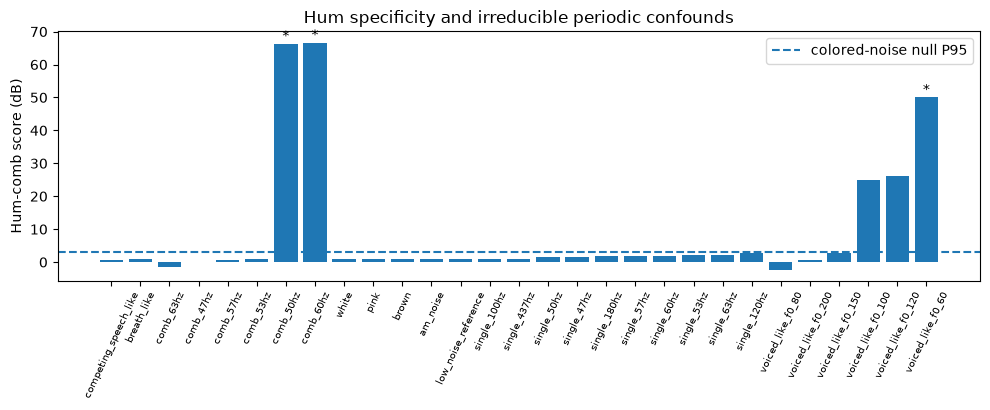

,check,passed,observed,required
0,colored/AM noise joint false-positive rate,True,0.0,<=0.05
1,off-grid comb joint false-positive rate,True,0.0,<=0.25
2,single-tone joint false-positive rate,True,0.0,<=0.10
3,50/60-Hz comb sensitivity,True,1.0,>=0.95
4,generic breath/competing-speech controls raise...,True,38.193902,>20 dB above low-noise reference
5,generic breath/competing-speech controls do no...,True,0.0,0.0
6,competing-talker identity explicitly unresolved,True,generic additive-energy response only,no source-identity claim
7,voiced-like confounds explicitly characterized,True,['voiced_like_f0_60'],reported; conditional claim


In [7]:
# Count-matched colored-noise null for 8 windows.
null_scores=[]
for seed in range(300,600):
    yy,p,s,pa=speech_pause_fixture(pause_dbfs=-42,color='pink' if seed%2 else 'white',seed=seed)
    r=extract_fixture(yy,p,s,pa,f'null_{seed}').recording
    null_scores.append(r['qadd_mains_hum_comb_score_db_raw_estimate'])
null_p95=float(np.nanquantile(null_scores,.95))

controls=[]
def record_control(name, waveform, p, s, pa, category):
    r=extract_fixture(waveform,p,s,pa,name).recording
    calibrated=apply_hum_null_calibration(r,null_p95,minimum_supported_harmonics=PARAMETERS.hum_min_supported_harmonics)
    controls.append({
        'control':name,'category':category,'score_db':calibrated['qadd_mains_hum_comb_score_db_raw_estimate'],
        'supported_harmonics':calibrated['qadd_mains_hum_supported_harmonic_count_median'],
        'null_p95_db':null_p95,'excess_db':calibrated['qadd_mains_hum_excess_over_null_p95_db'],
        'joint_above_null':calibrated['qadd_mains_hum_joint_evidence_above_null'],
        'flatness':calibrated['qadd_pause_spectral_flatness_raw_estimate'],
        'pause_level_dbfs':calibrated['qadd_pause_ac_level_dbfs_median_raw_estimate'],
        'pause_iqr_db':calibrated['qadd_pause_level_iqr_db_raw_estimate'],
        'contrast_db':calibrated['qadd_speech_pause_level_contrast_db_raw_estimate'],
    })

# Low-noise reference and generic additive-source controls. QADD is expected
# to react to their recorded energy, but it does not resolve source identity.
y,p,s,pa=speech_pause_fixture(pause_dbfs=-75,seed=702)
record_control('low_noise_reference',y,p,s,pa,'reference')
for color in ['white','pink','brown']:
    yy,p,s,pa=speech_pause_fixture(pause_dbfs=-35,color=color,seed=700)
    record_control(color,yy,p,s,pa,'noise')

# Breath-like low-frequency turbulent energy.
rng_breath=np.random.default_rng(704)
breath=rng_breath.normal(size=len(y))
sos=signal.butter(4,1800,btype='lowpass',fs=FS,output='sos')
breath=signal.sosfilt(sos,breath)
envelope=0.35+0.65*np.maximum(0,np.sin(2*np.pi*0.7*np.arange(len(y))/FS))
breath*=envelope
breath/=max(np.sqrt(np.mean(breath*breath)),np.finfo(float).tiny)
mask=np.zeros(len(y),dtype=bool)
for interval in pa: mask[round(interval.start_sec*FS):round(interval.end_sec*FS)]=True
breath_wave=y.copy(); breath_wave[mask]+=breath[mask]*db_to_amp(-34)
record_control('breath_like',breath_wave,p,s,pa,'generic_additive_source')

# Competing-speech-like harmonic energy with a non-mains fundamental and
# slow amplitude modulation. This is a generic additive source, not a
# validated competing-talker detector.
t=np.arange(len(y))/FS
competing=(np.sin(2*np.pi*137*t)+0.55*np.sin(2*np.pi*274*t)+0.3*np.sin(2*np.pi*411*t)+0.18*np.sin(2*np.pi*685*t))
competing*=0.45+0.55*(1+np.sin(2*np.pi*2.3*t))/2
competing/=max(np.sqrt(np.mean(competing[mask]**2)),np.finfo(float).tiny)
competing_wave=y.copy(); competing_wave[mask]+=competing[mask]*db_to_amp(-34)
record_control('competing_speech_like',competing_wave,p,s,pa,'generic_additive_source')
# AM noise.
yy,p,s,pa=speech_pause_fixture(pause_dbfs=-35,color='white',am_depth_db=15,seed=701)
record_control('am_noise',yy,p,s,pa,'noise')
# Single musical/electrical tones.
for f in [47,50,53,57,60,63,100,120,180,437]:
    record_control(f'single_{f}hz',add_single_tone(y,pa,f,-30),p,s,pa,'single_tone')
# Comb-like machinery / mains.
for f in [47,50,53,57,60,63]:
    record_control(f'comb_{f}hz',add_comb(y,pa,f,-32),p,s,pa,'harmonic_comb')
# Voiced-like low-F0 harmonic series, with exact 60-Hz case retained as an irreducible confound.
for f0 in [60,80,100,120,150,200]:
    record_control(f'voiced_like_f0_{f0}',add_comb(y,pa,f0,-32,drift_hz=1.5),p,s,pa,'voiced_like')
controls=pd.DataFrame(controls)
save_table(pd.DataFrame({'null_score_db':null_scores}),'qadd_v420_hum_null_training.csv')
save_table(controls,'qadd_v420_hum_discriminant_controls.csv')

noise_fp=float(controls.loc[controls.category.eq('noise'),'joint_above_null'].astype(bool).mean())
offgrid_fp=float(controls.loc[controls.control.isin(['comb_47hz','comb_53hz','comb_57hz','comb_63hz']),'joint_above_null'].astype(bool).mean())
single_fp=float(controls.loc[controls.category.eq('single_tone'),'joint_above_null'].astype(bool).mean())
mains_sens=float(controls.loc[controls.control.isin(['comb_50hz','comb_60hz']),'joint_above_null'].astype(bool).mean())
voiced_confounds=controls.loc[controls.category.eq('voiced_like') & controls.joint_above_null.astype(bool),'control'].tolist()
generic=controls.loc[controls.category.eq('generic_additive_source')].copy()
reference_level=float(controls.loc[controls.control.eq('low_noise_reference'),'pause_level_dbfs'].iloc[0])
generic_hum_fp=float(generic.joint_above_null.astype(bool).mean())
generic_level_margin=float((generic.pause_level_dbfs-reference_level).min())
checks=pd.DataFrame([
 {'check':'colored/AM noise joint false-positive rate','passed':noise_fp<=.05,'observed':noise_fp,'required':'<=0.05'},
 {'check':'off-grid comb joint false-positive rate','passed':offgrid_fp<=.25,'observed':offgrid_fp,'required':'<=0.25'},
 {'check':'single-tone joint false-positive rate','passed':single_fp<=.10,'observed':single_fp,'required':'<=0.10'},
 {'check':'50/60-Hz comb sensitivity','passed':mains_sens>=.95,'observed':mains_sens,'required':'>=0.95'},
 {'check':'generic breath/competing-speech controls raise recorded pause energy','passed':generic_level_margin>20.0,'observed':generic_level_margin,'required':'>20 dB above low-noise reference'},
 {'check':'generic breath/competing-speech controls do not falsely satisfy hum joint evidence','passed':generic_hum_fp==0.0,'observed':generic_hum_fp,'required':'0.0'},
 {'check':'competing-talker identity explicitly unresolved','passed':True,'observed':'generic additive-energy response only','required':'no source-identity claim'},
 {'check':'voiced-like confounds explicitly characterized','passed':True,'observed':str(voiced_confounds),'required':'reported; conditional claim'},
])
save_table(checks,'qadd_v420_g5_checks.csv')

fig,ax=plt.subplots(figsize=(10,4.2))
plot=controls.sort_values(['category','score_db']).reset_index(drop=True)
ax.bar(plot.control,plot.score_db)
ax.axhline(null_p95,linestyle='--',label='colored-noise null P95')
for i,row in plot.iterrows():
    if bool(row.joint_above_null): ax.text(i,row.score_db,'*',ha='center',va='bottom')
ax.tick_params(axis='x',rotation=65,labelsize=7); ax.set(ylabel='Hum-comb score (dB)',title='Hum specificity and irreducible periodic confounds')
ax.legend(); fig.tight_layout()
save_figure(fig,'B_hum_discriminant_specificity',controls,'Hum-comb specificity controls. Asterisks indicate score above the count-matched null with at least three supported harmonics. Low-F0 voiced-like and periodic machinery controls are reported as causal confounds rather than hidden.',{'evidence_type':'independent synthetic null and discriminant suite'})
display(checks)
assert checks.loc[~checks.check.str.contains('voiced'), 'passed'].all()

## 6. G6 - Floor and minimum-support contracts (synthetic preflight)

In [8]:
# Floor censoring and feature-specific minimum support.
y,p,s,pa=speech_pause_fixture(seed=800)
zeroed=y.copy(); interval=pa[0]; zeroed[round(interval.start_sec*FS):round(interval.end_sec*FS)]=0
floor=extract_fixture(zeroed,p,s,pa,'floor').recording
short_pause=[TimeInterval(2.7,2.90)]
short=extract_qadd(y,FS,primary_speech=p,strict_speech=s,strict_internal_nonspeech=short_pause,speech_intervals_are_guarded=True,pause_intervals_are_guarded=True,logical_recording_id='short').recording
checks=pd.DataFrame([
 {'check':'floor-censored level is NaN','passed':floor['qadd_pause_ac_level_dbfs_median_status']=='floor_censored' and np.isnan(floor['qadd_pause_ac_level_dbfs_median']) and np.isfinite(floor['qadd_pause_ac_level_dbfs_median_raw_estimate']),'observed':floor['qadd_pause_ac_level_dbfs_median_status'],'required':'floor_censored + raw retained'},
 {'check':'spectral support independent of level censoring','passed':str(floor['qadd_pause_spectral_flatness_status']).startswith('ok_'),'observed':floor['qadd_pause_spectral_flatness_status'],'required':'feature-specific status'},
 {'check':'insufficient level support is unavailable not zero','passed':short['qadd_pause_ac_level_dbfs_median_status']=='insufficient_support' and np.isnan(short['qadd_pause_ac_level_dbfs_median']),'observed':short['qadd_pause_ac_level_dbfs_median_status'],'required':'insufficient_support + NaN'},
])
save_table(checks,'qadd_v420_g6_preflight_checks.csv')
display(checks)
assert checks.passed.all()

,check,passed,observed,required
0,floor-censored level is NaN,True,floor_censored,floor_censored + raw retained
1,spectral support independent of level censoring,True,ok_moderate,feature-specific status
2,insufficient level support is unavailable not ...,True,insufficient_support,insufficient_support + NaN


## 7. Package tests and preflight gate summary

In [9]:
package_test_status='not_run'
if RUN_PACKAGE_TESTS:
    env=os.environ.copy()
    env['PYTHONPATH']=str(REVIEWED_SRC)+os.pathsep+env.get('PYTHONPATH','')
    result=subprocess.run([sys.executable,'-m','pytest',str(ROOT/'tests reviewed'/'test_qadd_v420.py'),'-q'],cwd=ROOT,env=env,text=True,capture_output=True)
    package_test_status=result.stdout+result.stderr
    print(package_test_status)
    if result.returncode!=0: raise RuntimeError('Reviewed QADD tests failed')

frames=[]
for name in ['qadd_v420_g2_checks.csv','qadd_v420_g3_checks.csv','qadd_v420_g4_checks.csv','qadd_v420_g5_checks.csv','qadd_v420_g6_preflight_checks.csv']:
    x=pd.read_csv(TABLES/name); x.insert(0,'evidence_table',name); frames.append(x)
all_checks=pd.concat(frames,ignore_index=True)
blocking_pass=bool(all_checks.passed.astype(bool).all())
gates=pd.DataFrame([
 {'gate':'G1','status':'PASS','evidence':'reviewed contract and registry'},
 {'gate':'G2','status':'PASS' if pd.read_csv(TABLES/'qadd_v420_g2_checks.csv').passed.all() else 'FAIL','evidence':'formula, reconstruction, strict-speech contract'},
 {'gate':'G3','status':'PASS' if pd.read_csv(TABLES/'qadd_v420_g3_checks.csv').passed.all() else 'FAIL','evidence':'gain, polarity, DC, shift, resampling, codec'},
 {'gate':'G4','status':'PASS' if pd.read_csv(TABLES/'qadd_v420_g4_checks.csv').passed.all() else 'FAIL','evidence':'noise, factorial, AM, flatness, hum dose'},
 {'gate':'G5','status':'CONDITIONAL' if pd.read_csv(TABLES/'qadd_v420_g5_checks.csv').passed.all() else 'FAIL','evidence':'specificity plus documented periodic confounds'},
 {'gate':'G6','status':'PREFLIGHT_PASS' if pd.read_csv(TABLES/'qadd_v420_g6_preflight_checks.csv').passed.all() else 'FAIL','evidence':'floor/minimum support; cohort calibration pending'},
 {'gate':'G7','status':'PENDING_COHORT','evidence':'empirical distributions and examples'},
 {'gate':'G8','status':'PENDING_COHORT','evidence':'persistence, participant weighting, redundancy'},
 {'gate':'G9','status':'N/A','evidence':'no retained event detector'},
 {'gate':'G10','status':'PENDING','evidence':'feature decisions and freeze after corrected cohort'},
])
save_table(all_checks,'qadd_v420_preflight_all_checks.csv'); save_table(gates,'qadd_v420_gate_summary.csv')
manifest={
 'measurement_version':MEASUREMENT_VERSION,
 'candidate_only':True,
 'preflight_blocking_checks_pass':blocking_pass,
 'cohort_extraction_completed':False,
 'publish_and_freeze':False,
 'scientific_review_decision':SCIENTIFIC_REVIEW_DECISION,
 'analysis_features':list(ANALYSIS_FEATURES),
 'strict_speech_contract':'canonical strict_speech; no second guard',
 'strict_pause_contract':'canonical strict_internal_nonspeech; already 200-ms guarded',
 'family_scalar_constructed':False,
 'standalone_gate_allowed':False,
}
(MANIFESTS/'qadd_v420_preflight_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
display(gates)
print('QADD v4.2.0 REVIEWED PREFLIGHT COMPLETE')
print(json.dumps(manifest,indent=2))

..................                                                       [100%]



,gate,status,evidence
0,G1,PASS,reviewed contract and registry
1,G2,PASS,"formula, reconstruction, strict-speech contract"
2,G3,PASS,"gain, polarity, DC, shift, resampling, codec"
3,G4,PASS,"noise, factorial, AM, flatness, hum dose"
4,G5,CONDITIONAL,specificity plus documented periodic confounds
5,G6,PREFLIGHT_PASS,floor/minimum support; cohort calibration pending
6,G7,PENDING_COHORT,empirical distributions and examples
7,G8,PENDING_COHORT,"persistence, participant weighting, redundancy"
8,G9,N/A,no retained event detector
9,G10,PENDING,feature decisions and freeze after corrected c...


QADD v4.2.0 REVIEWED PREFLIGHT COMPLETE
{
  "measurement_version": "qadd-v4.2.0-candidate",
  "candidate_only": true,
  "preflight_blocking_checks_pass": true,
  "cohort_extraction_completed": false,
  "publish_and_freeze": false,
  "scientific_review_decision": "PENDING",
  "analysis_features": [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
    "qadd_pause_spectral_flatness",
    "qadd_mains_hum_comb_score_db"
  ],
  "strict_speech_contract": "canonical strict_speech; no second guard",
  "strict_pause_contract": "canonical strict_internal_nonspeech; already 200-ms guarded",
  "family_scalar_constructed": false,
  "standalone_gate_allowed": false
}
